In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
data_q2=pd.read_csv('Documents/SEM 6/Machine Learning Principles and Techniques/data_q2.txt')
data_q2.head()

,Data Description:
0,First column: Serial No. indexing the rows
1,Second column: Body weight
2,Third column: Cranial Weight
3,Data set below:
4,Sno\tAttr1\tAttr2


In [3]:
file_path = "Documents/SEM 6/Machine Learning Principles and Techniques/data_q2.txt"
df = pd.read_csv(file_path, delim_whitespace=True, skiprows=8, names=["Serial_No", "Body_Weight", "Cranial_Weight"])
df.head()

C:\Users\Vishal Kumar\AppData\Local\Temp\ipykernel_3592\2166410353.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, skiprows=8, names=["Serial_No", "Body_Weight", "Cranial_Weight"])


,Serial_No,Body_Weight,Cranial_Weight
0,1,9100.00,94.40000
1,2,6804.00,78.73600
2,3,10425.18,86.48264
3,4,7031.00,63.74916
4,5,7938.00,76.89366


In [4]:
df.columns

Index(['Serial_No', 'Body_Weight', 'Cranial_Weight'], dtype='object')

In [5]:
df

,Serial_No,Body_Weight,Cranial_Weight
0,1,9100.00,94.40000
1,2,6804.00,78.73600
2,3,10425.18,86.48264
3,4,7031.00,63.74916
4,5,7938.00,76.89366
...,...,...,...
1109,1110,12.80,0.24000
1110,1111,4.90,0.15000
1111,1112,4.40,0.13400
1112,1113,280.00,1.82336


In [8]:
df.shape

(1114, 3)

In [10]:
df.describe()

,Serial_No,Body_Weight,Cranial_Weight
count,1114.000000,1.114000e+03,1114.000000
mean,557.500000,1.480411e+05,99.707601
std,321.728405,2.220711e+06,476.388624
min,1.000000,2.240000e+00,0.071000
25%,279.250000,3.974125e+01,0.826231
50%,557.500000,4.445000e+02,5.286000
75%,835.750000,5.997500e+03,53.906200
max,1114.000000,5.448150e+07,7636.179800


In [11]:
df.isnull().sum()

Serial_No         0
Body_Weight       0
Cranial_Weight    0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Serial_No       1114 non-null   int64  
 1   Body_Weight     1114 non-null   float64
 2   Cranial_Weight  1114 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 26.2 KB


In [16]:
df_train = df.sample(frac = 0.8, random_state = 200)
df_test = df.drop(df_train.index) 

len(df_train), len(df_test)

(891, 223)

In [72]:
n_train=len(df_train)

In [17]:
predictor_col =[1]
X_train = df_train[df_train.columns[predictor_col]]
X_test = df_test[df_test.columns[predictor_col]]

In [18]:
X_train

,Body_Weight
1032,11.70
435,14600.00
243,12.95
412,1389.00
506,67000.00
...,...
208,2625.00
395,7.20
994,361.00
443,85630.00


In [19]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [20]:
X_train

array([[1.17000000e+01],
       [1.46000000e+04],
       [1.29500000e+01],
       [1.38900000e+03],
       [6.70000000e+04],
       [2.24000000e+00],
       [5.76100000e+04],
       [5.99500000e+01],
       [9.18500000e+01],
       [1.07145000e+04],
       [7.98700000e+02],
       [1.22175000e+03],
       [1.34125000e+05],
       [3.46000000e+00],
       [4.26426471e+03],
       [1.25000000e+03],
       [1.36080000e+04],
       [3.63750000e+03],
       [4.94550000e+04],
       [5.67000000e+02],
       [3.53255785e+01],
       [2.75000000e+01],
       [1.46000000e+01],
       [2.36400000e+02],
       [1.88700000e+02],
       [1.21265000e+05],
       [3.95425000e+04],
       [6.23000000e+01],
       [5.61500000e+01],
       [3.19800000e+04],
       [3.10000000e+02],
       [3.80000000e+02],
       [2.81200000e+04],
       [2.75000000e+02],
       [4.69550000e+03],
       [6.12000000e+01],
       [5.44815000e+07],
       [9.15000000e+04],
       [8.00000000e+03],
       [1.95433946e+05],


In [21]:
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype = X_train.dtype)))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1), dtype = X_test.dtype)))

In [24]:
X_train.shape

(891, 2)

In [22]:
response_cols = [2]
Y_train = df_train[df_train.columns[response_cols]].to_numpy()
Y_test = df_test[df_test.columns[response_cols]].to_numpy()

In [23]:
Y_train.shape

(891, 1)

In [50]:
XTX = np.matmul(np.transpose(X_train),X_train)
print('XTX shape:',XTX.shape)
XTy = np.matmul(np.transpose(X_train),Y_train)

beta = np.matmul(np.linalg.inv(XTX),XTy)

print('beta: ',beta)
beta.shape

XTX shape: (2, 2)
beta:  [[1.44642427e-04]
 [7.82597127e+01]]


(2, 1)

In [53]:
beta[:1]

array([[0.00014464]])

In [55]:
beta[1:]

array([[78.25971274]])

In [58]:
y=beta[1:] + beta[:1].T*X_train

In [59]:
Y_pred = np.matmul(X_test, beta)
Y_pred

array([[  79.57595883],
       [  79.76763608],
       [ 159.25947191],
       [  78.64590802],
       [  93.88109487],
       [  78.53453335],
       [  78.2633288 ],
       [ 102.84892535],
       [  78.26075417],
       [  78.2977537 ],
       [ 124.11136213],
       [  85.13022803],
       [  78.28459124],
       [  78.26230184],
       [  78.26336496],
       [  78.65892584],
       [  78.95681692],
       [  79.01120247],
       [  79.98674332],
       [  79.14637082],
       [  78.90959117],
       [  79.46458416],
       [  78.26694486],
       [ 248.22179669],
       [  78.26124595],
       [  78.26263452],
       [  82.22146882],
       [  78.36819456],
       [  78.43211205],
       [  78.27316449],
       [  78.27086467],
       [  78.40182393],
       [  78.26164372],
       [  78.26247541],
       [  78.26111577],
       [  78.26062399],
       [  78.26063845],
       [  78.26182452],
       [  78.65314014],
       [  91.37675589],
       [  82.69730837],
       [  78.266

In [61]:
Y_pred.shape

(223, 1)

In [62]:
y_mean = np.mean(Y_test)
SS_total = np.sum((Y_test - y_mean) ** 2)
SS_residual = np.sum((Y_test - Y_pred) ** 2)
R2 = 1 - (SS_residual / SS_total)

print(f"R² Score on Test Data: {R2:.4f}")

R² Score on Test Data: 0.7258


C:\Users\Vishal Kumar\AppData\Local\Temp\ipykernel_3592\3417413777.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


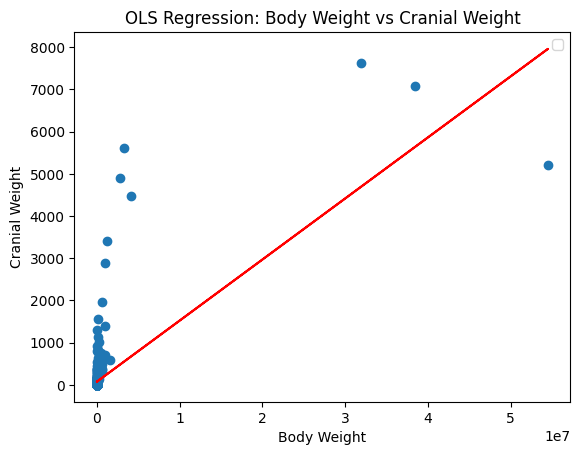

In [63]:
plt.scatter(df['Body_Weight'],df['Cranial_Weight'])
plt.plot(X_train,y,color='red')
plt.xlabel("Body Weight")
plt.ylabel("Cranial Weight")
plt.title("OLS Regression: Body Weight vs Cranial Weight")
plt.legend()
plt.show()


In [65]:
lambdas = np.array([0,1e-5,1e-4,1e-3,1e-2,1e-1,1,2,5,10,20,50,100,200,500,2000,10000])
I = np.identity(XTX.shape[0])

for lambda_ in lambdas:
  print('lambda:',lambda_,'cond(XTX + lambda I):', np.linalg.cond(XTX + lambda_ * I))

lambda: 0.0 cond(XTX + lambda I): 4546399635847.381
lambda: 1e-05 cond(XTX + lambda I): 4546399584613.224
lambda: 0.0001 cond(XTX + lambda I): 4546399123505.861
lambda: 0.001 cond(XTX + lambda I): 4546394512437.379
lambda: 0.01 cond(XTX + lambda I): 4546348402266.9795
lambda: 0.1 cond(XTX + lambda I): 4545887351999.916
lambda: 1.0 cond(XTX + lambda I): 4541281987237.321
lambda: 2.0 cond(XTX + lambda I): 4536175847021.346
lambda: 5.0 cond(XTX + lambda I): 4520926089847.689
lambda: 10.0 cond(XTX + lambda I): 4495736410665.816
lambda: 20.0 cond(XTX + lambda I): 4446189882150.533
lambda: 50.0 cond(XTX + lambda I): 4303893086654.202
lambda: 100.0 cond(XTX + lambda I): 4085947230082.3584
lambda: 200.0 cond(XTX + lambda I): 3710185330932.171
lambda: 500.0 cond(XTX + lambda I): 2907911786552.1655
lambda: 2000.0 cond(XTX + lambda I): 1397243738441.4307
lambda: 10000.0 cond(XTX + lambda I): 370554734722.2429


In [67]:
!pip install scipy


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import scipy.linalg

# Now we are ready for finding beta
# print('X shape:',X.shape,'y shape:',y.shape)

betas = []

for lambda_ in lambdas:
  beta = scipy.linalg.solve(XTX + lambda_ * I, XTy)
  print('lambda:',lambda_)
  print('beta:',beta)
  print('***************')
  betas.append(beta)


lambda: 0.0
beta: [[1.44642427e-04]
 [7.82597127e+01]]
***************
lambda: 1e-05
beta: [[1.44642427e-04]
 [7.82597119e+01]]
***************
lambda: 0.0001
beta: [[1.44642427e-04]
 [7.82597039e+01]]
***************
lambda: 0.001
beta: [[1.44642430e-04]
 [7.82596246e+01]]
***************
lambda: 0.01
beta: [[1.44642454e-04]
 [7.82588308e+01]]
***************
lambda: 0.1
beta: [[1.44642691e-04]
 [7.82508945e+01]]
***************
lambda: 1.0
beta: [[1.44645067e-04]
 [7.81716198e+01]]
***************
lambda: 2.0
beta: [[1.44647701e-04]
 [7.80837250e+01]]
***************
lambda: 5.0
beta: [[1.44655568e-04]
 [7.78212224e+01]]
***************
lambda: 10.0
beta: [[1.44668563e-04]
 [7.73876184e+01]]
***************
lambda: 20.0
beta: [[1.44694122e-04]
 [7.65347464e+01]]
***************
lambda: 50.0
beta: [[1.44767528e-04]
 [7.40853123e+01]]
***************
lambda: 100.0
beta: [[1.44879959e-04]
 [7.03336887e+01]]
***************
lambda: 200.0
beta: [[1.45073801e-04]
 [6.38654895e+01]]
*******

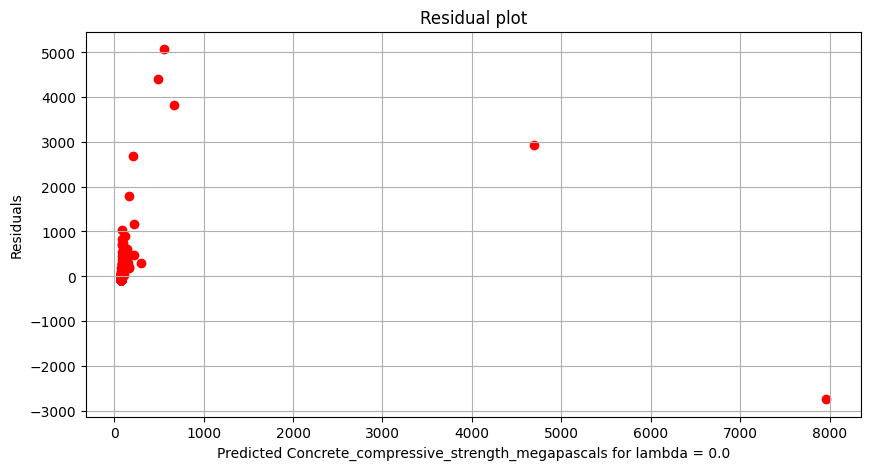

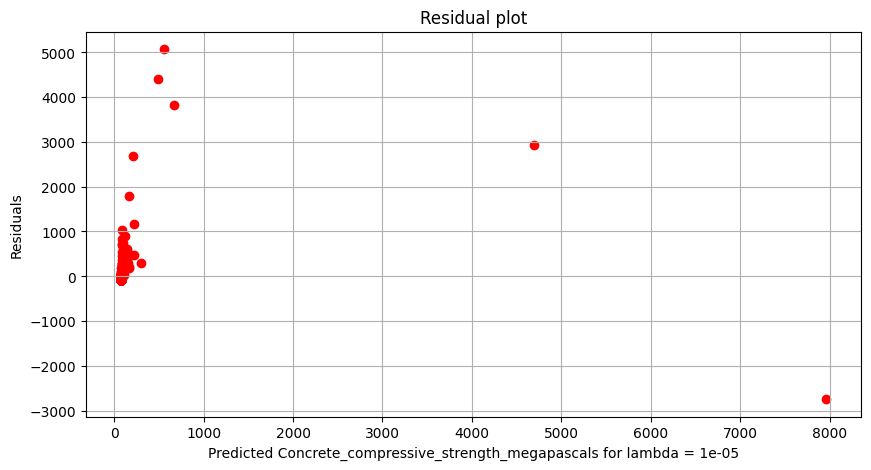

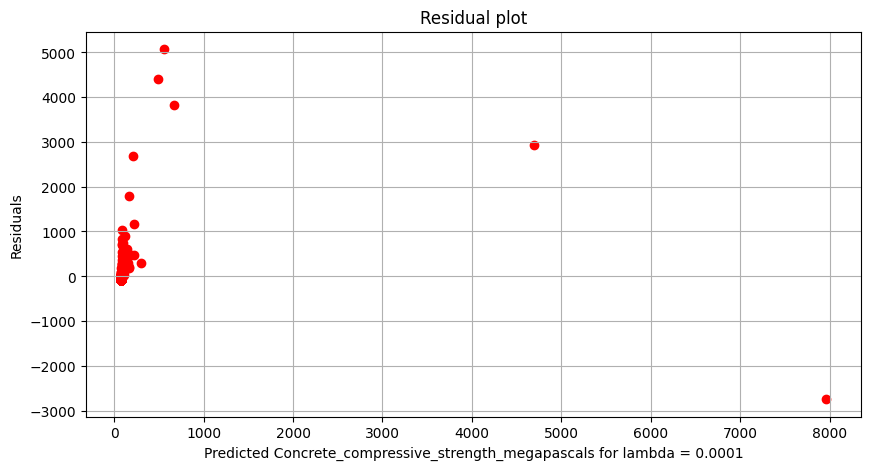

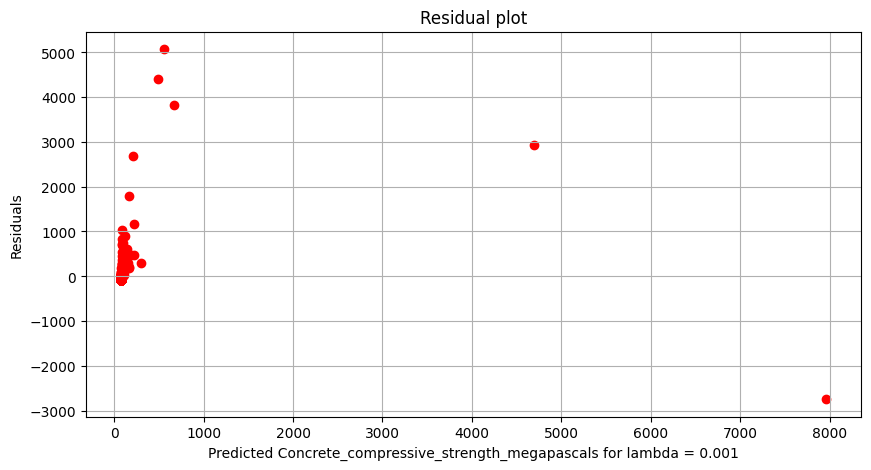

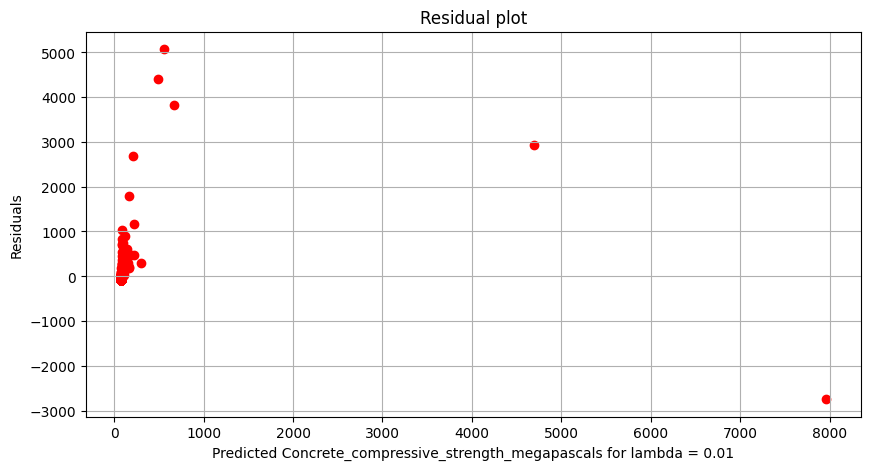

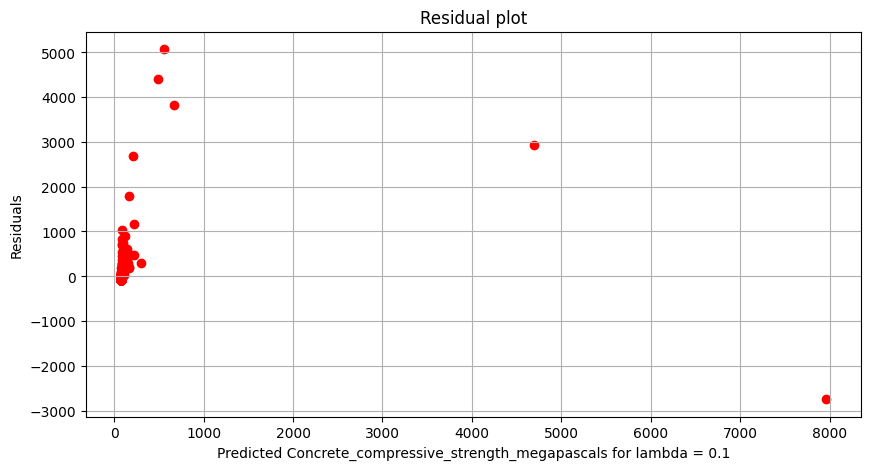

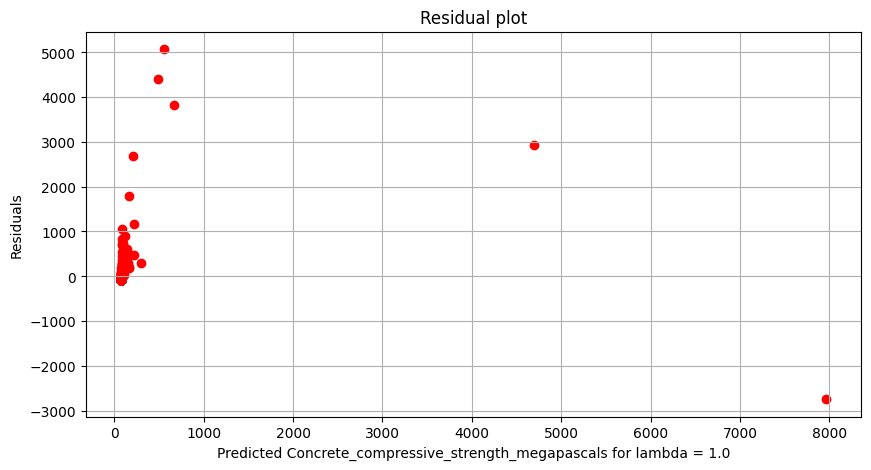

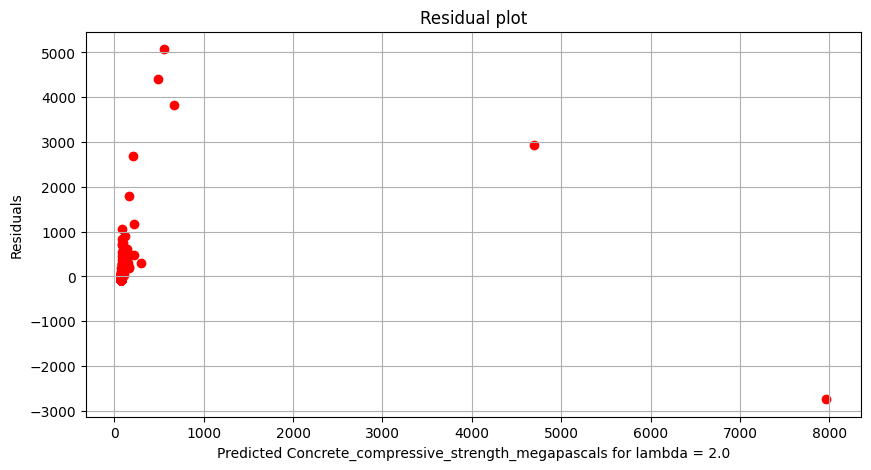

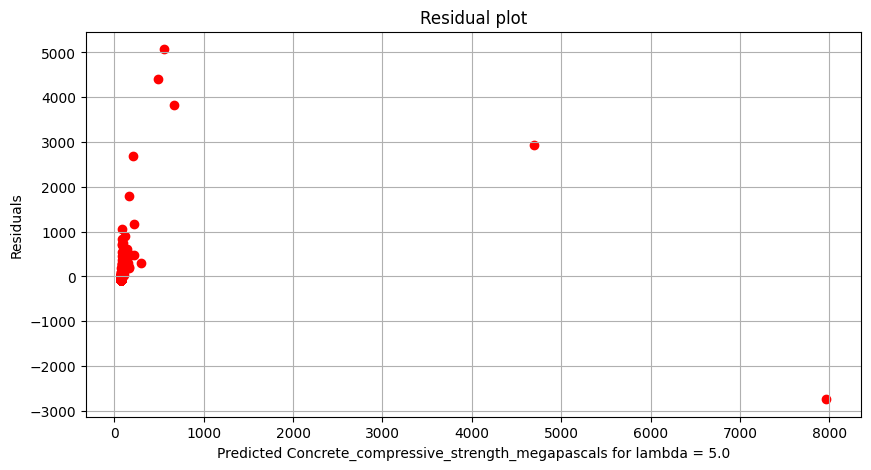

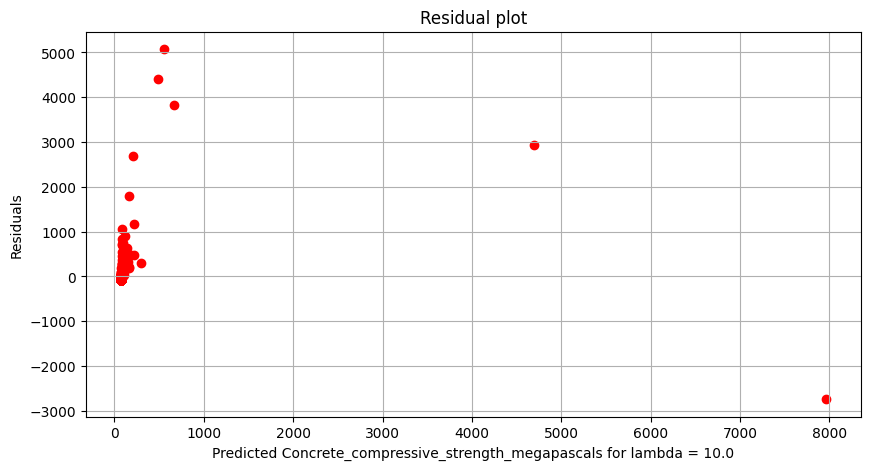

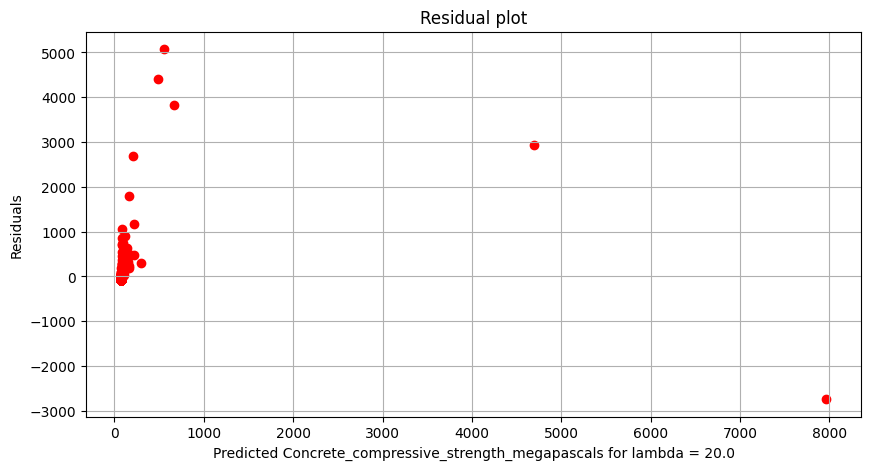

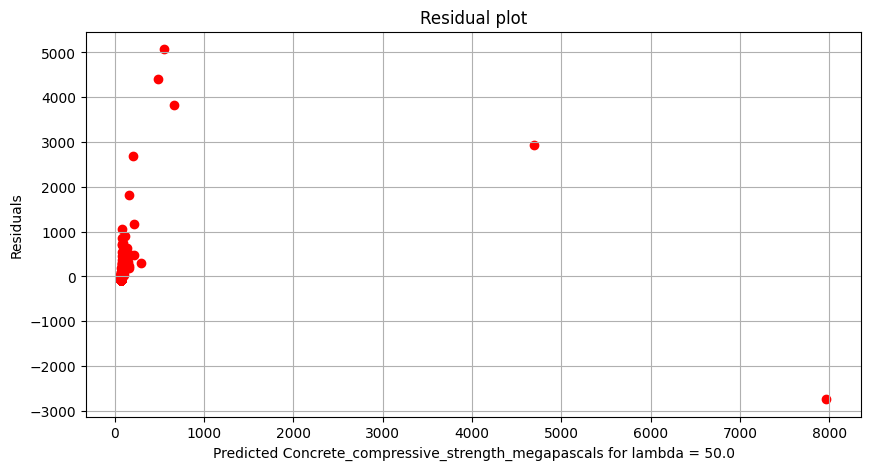

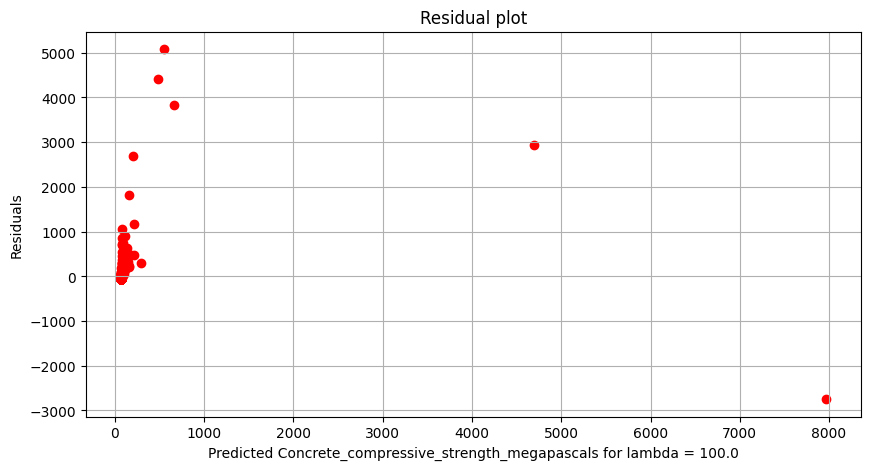

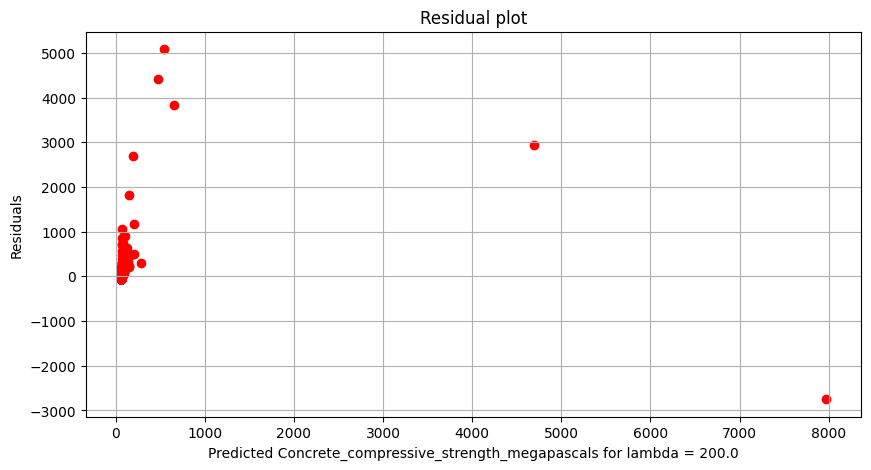

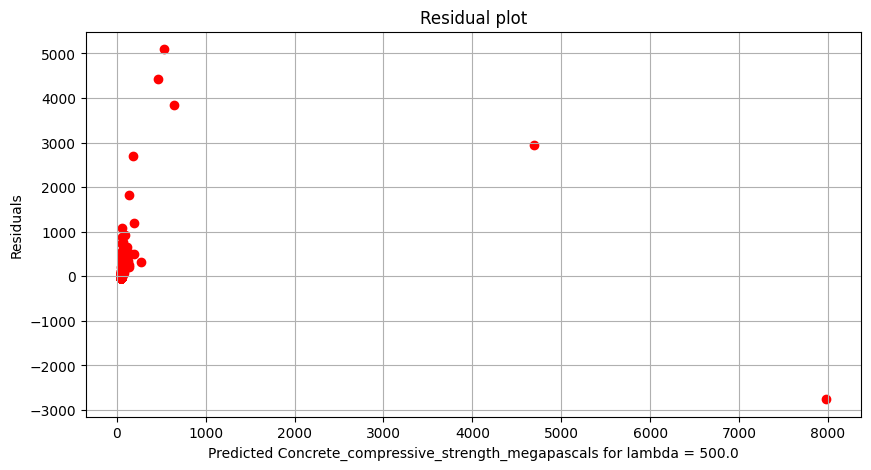

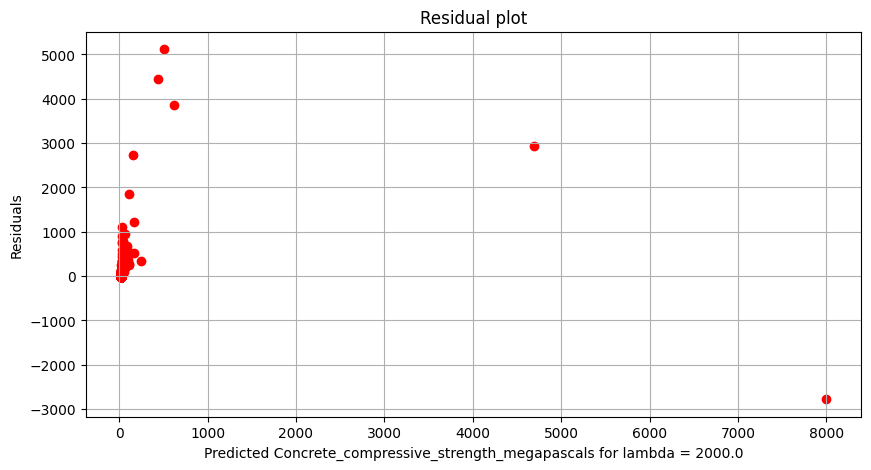

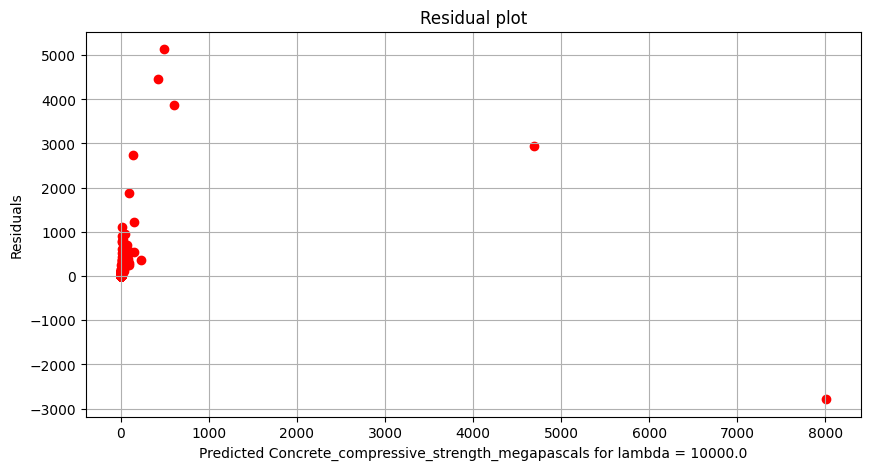

In [74]:
beta_idx = 0
for lambda_ in lambdas:
  beta = betas[beta_idx]
  beta_idx += 1
  xlabel = 'Predicted Concrete_compressive_strength_megapascals for lambda = ' + str(lambda_)
  e_i_residuals_list = []
  y_pred_list = []

  for i in range(n_train):

    x_i = X_train[i,:]          # Access i-th row of X
    y_i = Y_train[i]            # Access i-th row of y

    y_pred_i = np.dot(x_i, beta) # Compute the prediction obtained using the regression coefficients
    e_i = y_i - y_pred_i         # Compute the difference between the actual observation y_i and prediction y_pred_i

    e_i_residuals_list.append(e_i) # Append the value of e_i to the list
    y_pred_list.append(y_pred_i)

  #print(e_i_residuals_list)

  # Plot the residuals e_i against the actual observations y_i
  plt.figure(figsize = (10, 5))  # Set figure size
  plt.scatter(y_pred_list, e_i_residuals_list, color = 'r')
  plt.title("Residual plot")
  plt.xlabel(xlabel)
  plt.ylabel("Residuals")
  plt.grid()
  plt.show()

In [77]:
residual=y-Y_train
residual

array([[ 78.02140506,  78.01985739],
       [ 22.77149218,  20.65985739],
       [ 77.95158586,  77.94985739],
       ...,
       [ 74.01192866,  73.95985739],
       [-60.80955623, -73.19514261],
       [ 38.33346138,  36.67455739]], shape=(891, 2))

ValueError: x and y must be the same size

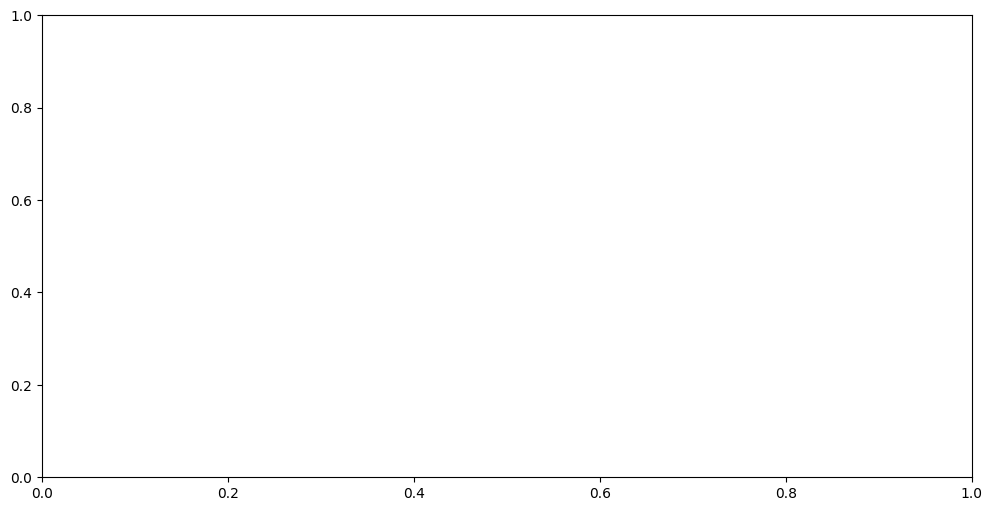

In [78]:
plt.figure(figsize=(12,6))
plt.scatter(residual,Y_train,color='r')

In [79]:
Y_train.shape

(891, 1)